In [19]:
import numpy as np
import torch
import matplotlib.pyplot as plt

%reload_ext autoreload
%autoreload 2

# This is all you really need if they are in the same folder
from LQR import LQR, run_monte_carlo_implicit, train_nn, run_policy_iteration, Net_DGM, FFN, device, train_dgm_linear_pde

print(f"Running on: {device}")

Running on: cpu


In [9]:
# Parameters
H, M, C, D, R, T = [[0.1, 0.], [0., 0.1]], np.eye(2), np.eye(2), np.eye(2)*0.1, np.eye(2), 1.0
x0 = [[1.0, 1.0]]
lqr_sim = LQR(H, M, C, D, R, T, sigma=0.5)

# Calculate Analytical Ground Truth
lqr_sim.solve_riccati(torch.linspace(0, T, 100))
v_true = lqr_sim.get_value(torch.tensor([0.0]), torch.tensor([x0])).item()
a_true = lqr_sim.get_control(torch.tensor([0.0]), torch.tensor([x0])).numpy()
print(f"True Value: {v_true:.4f}")

True Value: 0.6541


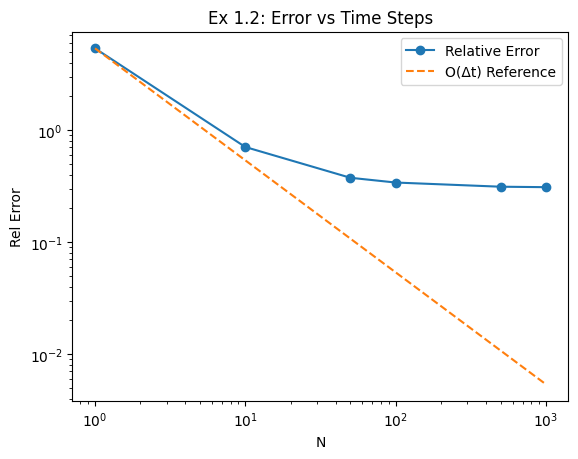

In [22]:
N_steps_list = [1, 10, 50, 100, 500, 1000]
errors_N = [abs(v_true - run_monte_carlo_implicit(lqr_sim, x0, n, 100000)) / abs(v_true) for n in N_steps_list]

plt.loglog(N_steps_list, errors_N, '-o', label='Relative Error')
plt.loglog(N_steps_list, [errors_N[0]/n for n in N_steps_list], '--', label='O(Δt) Reference')
plt.title("Ex 1.2: Error vs Time Steps")
plt.xlabel("N"); plt.ylabel("Rel Error"); plt.legend(); plt.show()

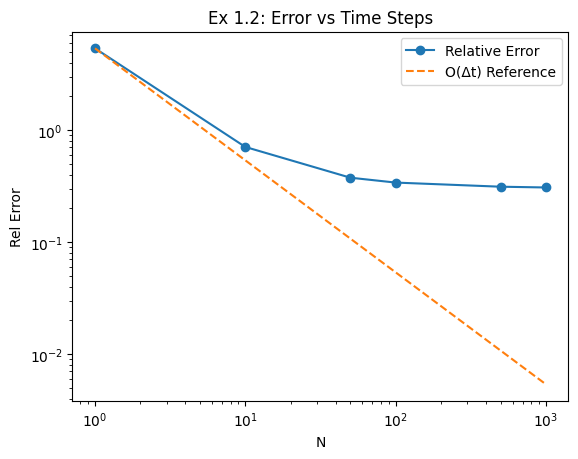

In [15]:
# --- Exercise 2 ---
N_steps_list = [1, 10, 50, 100, 500, 1000]
errors_N = [abs(v_true - run_monte_carlo_implicit(lqr_sim, x0, n, 100000)) / abs(v_true) for n in N_steps_list]

plt.loglog(N_steps_list, errors_N, '-o', label='Relative Error')
plt.loglog(N_steps_list, [errors_N[0]/n for n in N_steps_list], '--', label='O(Δt) Reference')
plt.title("Ex 1.2: Error vs Time Steps")
plt.xlabel("N"); plt.ylabel("Rel Error"); plt.legend(); plt.show()

Running Exercise 3.1: DGM for Linear PDE...
MC Validation Value (alpha=[1,1]): 0.6234
Epoch 0 | Loss: 1.0667e+02 | Rel Error: 0.9861
Epoch 200 | Loss: 5.0281e+01 | Rel Error: 5.4001
Epoch 400 | Loss: 2.8429e+01 | Rel Error: 17.6661
Epoch 600 | Loss: 2.3433e+01 | Rel Error: 20.6593
Epoch 800 | Loss: 1.9636e+01 | Rel Error: 21.7798
Epoch 1000 | Loss: 1.5130e+01 | Rel Error: 22.0871


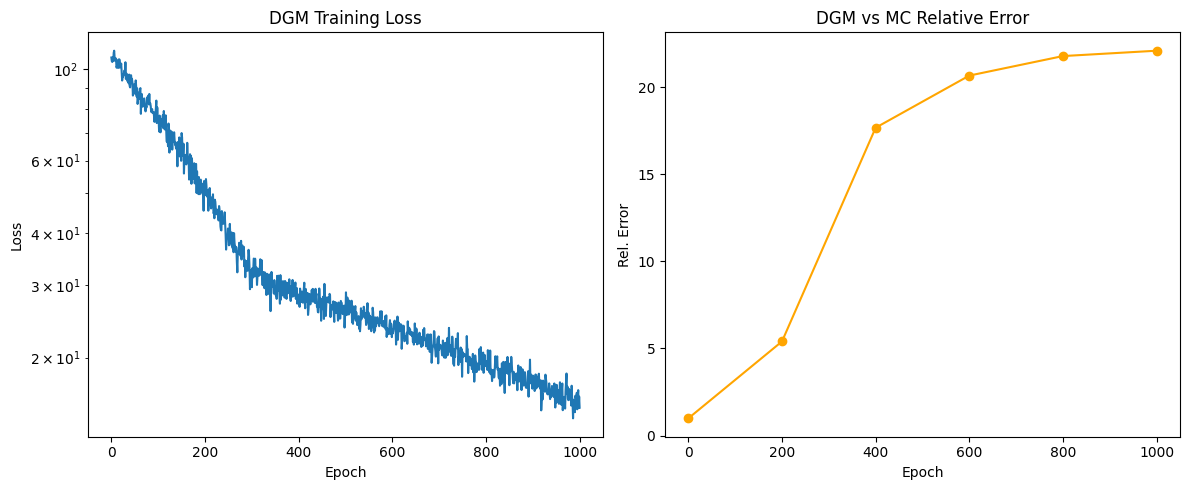

In [20]:
# --- Exercise 3.1 ---
print("Running Exercise 3.1: DGM for Linear PDE...")

dgm_model = Net_DGM().to(device)
alpha_const = [1.0, 1.0]

# Get MC Ground Truth for the constant control (for validation)
v_mc_const = run_monte_carlo_implicit(lqr_sim, x0, N_steps=100, M_samples=100000, alpha_val=alpha_const)
print(f"MC Validation Value (alpha=[1,1]): {v_mc_const:.4f}")

# Train the DGM Model
loss_history, error_history = train_dgm_linear_pde(
    lqr_sim,           # lqr_obj
    dgm_model,         # dgm_model
    x0,                # x_test_point (which is [[1.0, 1.0]])
    alpha_val=alpha_const, 
    v_mc_target=v_mc_const, 
    epochs=1001, 
    batch_size=512
)

# Plotting
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.yscale('log')
plt.title("DGM Training Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")

plt.subplot(1, 2, 2)
# Error history is usually recorded every 100/200 epochs
plt.plot(range(0, 1001, 200), error_history, '-o', color='orange')
plt.title("DGM vs MC Relative Error")
plt.xlabel("Epoch"); plt.ylabel("Rel. Error")

plt.tight_layout()
plt.show()

Epoch 0 | Loss: 1.6418e+01 | Rel Error: 22.1115
Epoch 200 | Loss: 1.2172e+01 | Rel Error: 22.2211
Epoch 400 | Loss: 8.6286e+00 | Rel Error: 22.5951
Epoch 600 | Loss: 6.4416e+00 | Rel Error: 22.9703
Epoch 800 | Loss: 4.7143e+00 | Rel Error: 22.9987
Epoch 1000 | Loss: 3.2152e+00 | Rel Error: 23.2303


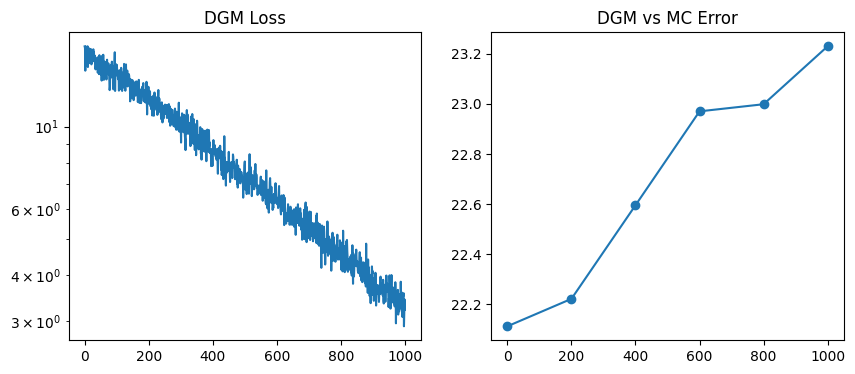

In [23]:
# Exercise 3.1: DGM for Linear PDE
v_mc_const = run_monte_carlo_implicit(lqr_sim, x0, 100, 100000, alpha_val=[1.0, 1.0])
loss_31, err_31 = train_dgm_linear_pde(lqr_sim, dgm_model, x0, [1.0, 1.0], v_mc_const)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(loss_31); plt.yscale('log'); plt.title("DGM Loss")
plt.subplot(1,2,2); plt.plot(range(0, 1001, 200), err_31, '-o'); plt.title("DGM vs MC Error")
plt.show()

Iteration 1: Value Error = 16.8721, Action Error = 0.9599
Iteration 2: Value Error = 15.5950, Action Error = 0.7025
Iteration 3: Value Error = 10.9143, Action Error = 0.4257
Iteration 4: Value Error = 7.4059, Action Error = 0.4199
Iteration 5: Value Error = 7.3823, Action Error = 0.1861


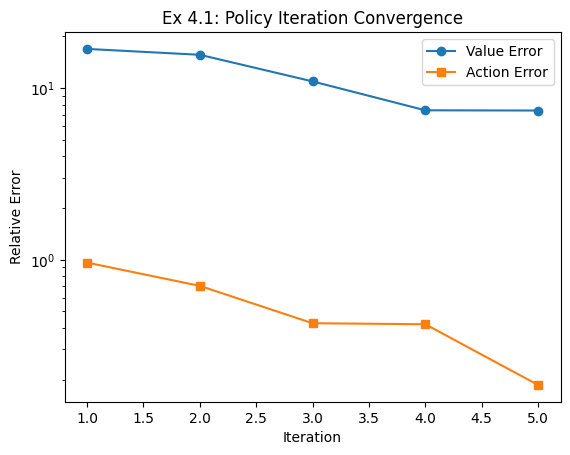

In [ ]:
# Exercise 4.1: Policy Iteration Algorithm (PIA)
pia_results = run_policy_iteration(lqr_sim, x0)

plt.figure()
plt.plot(range(1, 6), pia_results["v_err"], '-o', label="Value Error")
plt.plot(range(1, 6), pia_results["a_err"], '-s', label="Action Error")
plt.yscale('log'); plt.xlabel("Iteration"); plt.ylabel("Relative Error")
plt.title("Ex 4.1: Policy Iteration Convergence"); plt.legend(); plt.show()